In [18]:
import sys, pathlib
repo_root = pathlib.Path("/Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


In [19]:
%load_ext autoreload
%autoreload 2
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
# Load plans and pick one sample
from thesis_package import config, io
import resplan_utils as R

plans = io.load_data(config.PKL_PATH)
plan_idx = 0  # change this to inspect another plan
raw_plan = R.normalize_keys(plans[plan_idx].copy())
plan_idx


0

In [21]:
# Extract room and structural instances
from thesis_package.plan_utils import extract_room_instances, split_walls

rooms = extract_room_instances(raw_plan)
structural = split_walls(raw_plan)

room_counts = {k: len(v) for k, v in rooms.items()}
struct_counts = {k: len(v) for k, v in structural.items()}
room_counts, struct_counts


({'bedroom': 2,
  'bathroom': 2,
  'kitchen': 1,
  'living': 1,
  'balcony': 2,
  'storage': 1,
  'stair': 0,
  'veranda': 0,
  'parking': 0},
 {'interior_wall': 6,
  'exterior_wall': 5,
  'door': 7,
  'window': 4,
  'front_door': 1})

In [23]:
# Build relations/graph bundle
from thesis_package.graph import export_graph

graph_bundle = export_graph(raw_plan, rooms, structural)
relations_summary = {k: len(v) for k, v in graph_bundle['relations'].items()}
relations_summary


{'bounded_by': 2,
 'adjacent_to': 1,
 'hosts_opening': 22,
 'connected_via_door': 8}

JSON saved to: /Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/resplan_json/plan_00000.json


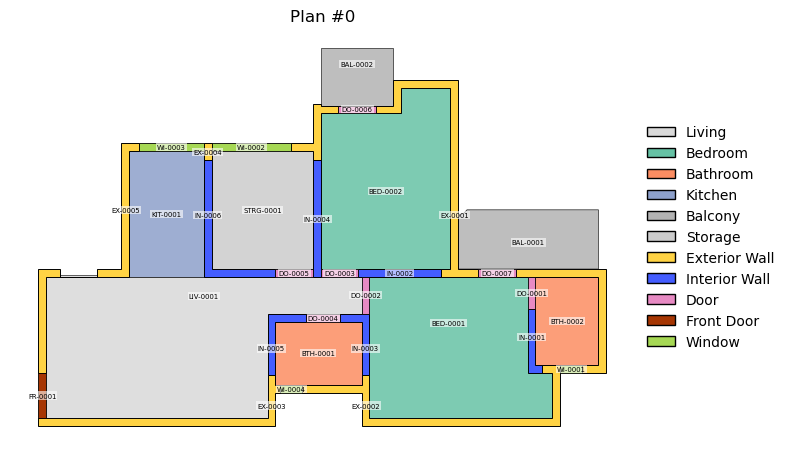

In [24]:
# Assemble artefact and persist JSON/plot outputs
from thesis_package import config
from thesis_package.visualize import plot_plan_json

# Ekspor main artefact (JSON + plot tanpa label)
json_path = config.export_one(plan_idx, raw_plan)
print(f"JSON saved to: {json_path}")

# Bangun nama file untuk plot berlabel dan simpan tampilannya
label_path = config.PLOT_LABEL_DIR / f"plan_{plan_idx:05d}_ids.png"

ax = plot_plan_json(json_path, show_ids=True, figsize=(8, 7))
ax.figure.savefig(label_path, dpi=200, bbox_inches="tight")


